# CAMUV: `lingam` vs `ruslingam` Execution Time Comparison

Compares the `fit()` execution time of `lingam.CAMUV` and `ruslingam.CAMUV` (both
using the default `alpha=0.01`, `num_explanatory_vals=2`, `independence="hsic"`)
across a grid of feature counts and sample counts.

- Feature counts: 4, 6, 8, 10
- Sample counts: 200 / 500 / 1,000
- For each (features, samples) combination, runs are repeated with 5 different random
  seeds, and the mean and standard deviation of the execution time are aggregated.
- Data generation reuses `make_confounded_sem` (a mix of plain direct edges and a pair
  sharing an unobserved latent confounder through two different non-monotonic
  functions) and `fmt` (time formatting) from `benchmarks/bench_camuv.py` as-is.

**Note:** CAMUV's combinatorial parent search plus a GAM fit per candidate parent set
is far more expensive per `fit()` call than DirectLiNGAM's causal ordering — true for
*both* implementations — so this grid is deliberately much smaller than
`direct_lingam_notebook.ipynb`'s. The whole benchmark finishes in well under a minute.

## Execution Environment

In [1]:
import importlib.metadata
import os
import platform
import sys

import numpy as np
import lingam
import ruslingam

print("execution environment")
print("-" * 40)
print(f"platform     : {platform.platform()}")
print(f"processor    : {platform.processor() or platform.machine()}")
print(f"logical CPUs : {os.cpu_count()}")
print(f"python       : {sys.version.split()[0]}")
print(f"numpy        : {np.__version__}")
print(f"lingam       : {lingam.__version__}")
print(f"ruslingam    : {importlib.metadata.version('ruslingam')}")

execution environment
----------------------------------------
platform     : Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.39
processor    : x86_64
logical CPUs : 24
python       : 3.12.3
numpy        : 2.2.6
lingam       : 1.13.0
ruslingam    : 0.1.0


## Setup

In [2]:
import sys
import time
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

BENCH_DIR = Path.cwd()
if str(BENCH_DIR) not in sys.path:
    sys.path.insert(0, str(BENCH_DIR))

# Reuse the bench_camuv.py helpers (avoid duplicating the implementation)
from bench_camuv import make_confounded_sem, fmt, adjacency_matrices_match

In [3]:
FEATURE_SIZES = [4, 6, 8, 10]
SAMPLE_SIZES = [200, 500, 1000]
SEEDS = range(5)

print(f"features      = {FEATURE_SIZES}")
print(f"samples       = {SAMPLE_SIZES}")
print(f"seeds         = {list(SEEDS)}")
print(
    f"total configs = {len(FEATURE_SIZES) * len(SAMPLE_SIZES)} "
    f"(x {len(list(SEEDS))} seeds x 2 libraries = "
    f"{len(FEATURE_SIZES) * len(SAMPLE_SIZES) * len(list(SEEDS)) * 2} fit() calls)"
)

features      = [4, 6, 8, 10]
samples       = [200, 500, 1000]
seeds         = [0, 1, 2, 3, 4]
total configs = 12 (x 5 seeds x 2 libraries = 120 fit() calls)


## Running the Benchmark

For each `(features, samples)` combination, generates data from `make_confounded_sem`
for each of 5 seeds, fits both implementations once each, and measures the elapsed
time. Also records whether `adjacency_matrix_` matches between the two
implementations (NaN-aware; no extra `fit()` calls are needed for this).

In [4]:
records = []
header = (
    f"{'features':>8} {'samples':>8} {'seed':>4} | "
    f"{'lingam':>12} {'ruslingam':>12} | {'speedup':>8}  {'adj. match':>10}"
)
print(header)
print("-" * len(header))

t_start = time.perf_counter()
for p in FEATURE_SIZES:
    for n in SAMPLE_SIZES:
        for seed in SEEDS:
            X = make_confounded_sem(seed, n, p)

            t0 = time.perf_counter()
            ref_model = lingam.CAMUV().fit(X)
            ref_time = time.perf_counter() - t0

            t0 = time.perf_counter()
            rus_model = ruslingam.CAMUV().fit(X)
            rus_time = time.perf_counter() - t0

            match = adjacency_matrices_match(ref_model.adjacency_matrix_, rus_model.adjacency_matrix_)
            speedup = ref_time / rus_time if rus_time else float("inf")

            print(
                f"{p:>8} {n:>8} {seed:>4} | "
                f"{fmt(ref_time):>12} {fmt(rus_time):>12} | "
                f"{speedup:>7.1f}x  {('yes' if match else 'NO'):>10}"
            )

            records.append(
                {
                    "features": p,
                    "samples": n,
                    "seed": seed,
                    "lingam_time": ref_time,
                    "ruslingam_time": rus_time,
                    "adjacency_matrix_match": match,
                }
            )

elapsed = time.perf_counter() - t_start
print("-" * len(header))
print(f"total elapsed: {elapsed:.1f} s")

raw_df = pd.DataFrame(records)
raw_df.head()

features  samples seed |       lingam    ruslingam |  speedup  adj. match
-------------------------------------------------------------------------
       4      200    0 |     33.57 ms      8.75 ms |     3.8x         yes
       4      200    1 |     12.06 ms      2.46 ms |     4.9x         yes
       4      200    2 |     15.48 ms      2.94 ms |     5.3x         yes
       4      200    3 |     15.45 ms      4.38 ms |     3.5x         yes
       4      200    4 |     29.06 ms      7.52 ms |     3.9x         yes


       4      500    0 |    177.88 ms     26.40 ms |     6.7x         yes
       4      500    1 |    108.33 ms     14.33 ms |     7.6x         yes
       4      500    2 |     47.66 ms     16.37 ms |     2.9x         yes


       4      500    3 |    230.55 ms     35.01 ms |     6.6x         yes
       4      500    4 |     94.07 ms      9.10 ms |    10.3x         yes


       4     1000    0 |    190.24 ms     32.14 ms |     5.9x         yes


       4     1000    1 |    263.87 ms     64.72 ms |     4.1x         yes


...

      10     1000    1 |     2.098 s     248.28 ms |     8.4x         yes


      10     1000    2 |     1.100 s     113.34 ms |     9.7x         yes


      10     1000    3 |     1.682 s     197.37 ms |     8.5x         yes


      10     1000    4 |     1.249 s     154.86 ms |     8.1x         yes
-------------------------------------------------------------------------
total elapsed: 23.8 s


,features,samples,seed,lingam_time,ruslingam_time,adjacency_matrix_match
0,4,200,0,0.033574,0.008747,True
1,4,200,1,0.012059,0.002462,True
2,4,200,2,0.015477,0.002937,True
3,4,200,3,0.015453,0.004381,True
4,4,200,4,0.029057,0.007524,True


## Aggregation

In [5]:
summary = (
    raw_df.groupby(["features", "samples"])
    .agg(
        lingam_mean=("lingam_time", "mean"),
        lingam_std=("lingam_time", "std"),
        ruslingam_mean=("ruslingam_time", "mean"),
        ruslingam_std=("ruslingam_time", "std"),
        match_rate=("adjacency_matrix_match", "mean"),
    )
    .reset_index()
)
summary["speedup"] = summary["lingam_mean"] / summary["ruslingam_mean"]
summary

,features,samples,lingam_mean,lingam_std,ruslingam_mean,ruslingam_std,match_rate,speedup
0,4,200,0.021124,0.009541,0.005210,0.002796,1.0,4.054275
1,4,500,0.131700,0.072335,0.020242,0.010367,1.0,6.506435
2,4,1000,0.199661,0.042796,0.052719,0.021301,1.0,3.787293
3,6,200,0.035219,0.009379,0.006084,0.001440,1.0,5.788983
4,6,500,0.161885,0.105225,0.048904,0.039441,1.0,3.310283
5,6,1000,0.397391,0.084830,0.064526,0.017258,1.0,6.158613
6,8,200,0.044156,0.010568,0.007470,0.001592,1.0,5.911473
7,8,500,0.203233,0.135783,0.047643,0.038774,1.0,4.265732
8,8,1000,0.993796,0.448509,0.123648,0.066855,1.0,8.037323
9,10,200,0.154922,0.123449,0.029613,0.030501,1.0,5.231588


## Charts

For each feature count, plots a chart with samples on the x-axis and `fit()` execution
time (seconds, log scale) on the y-axis. Error bars show the standard deviation across
the 5 seeds.

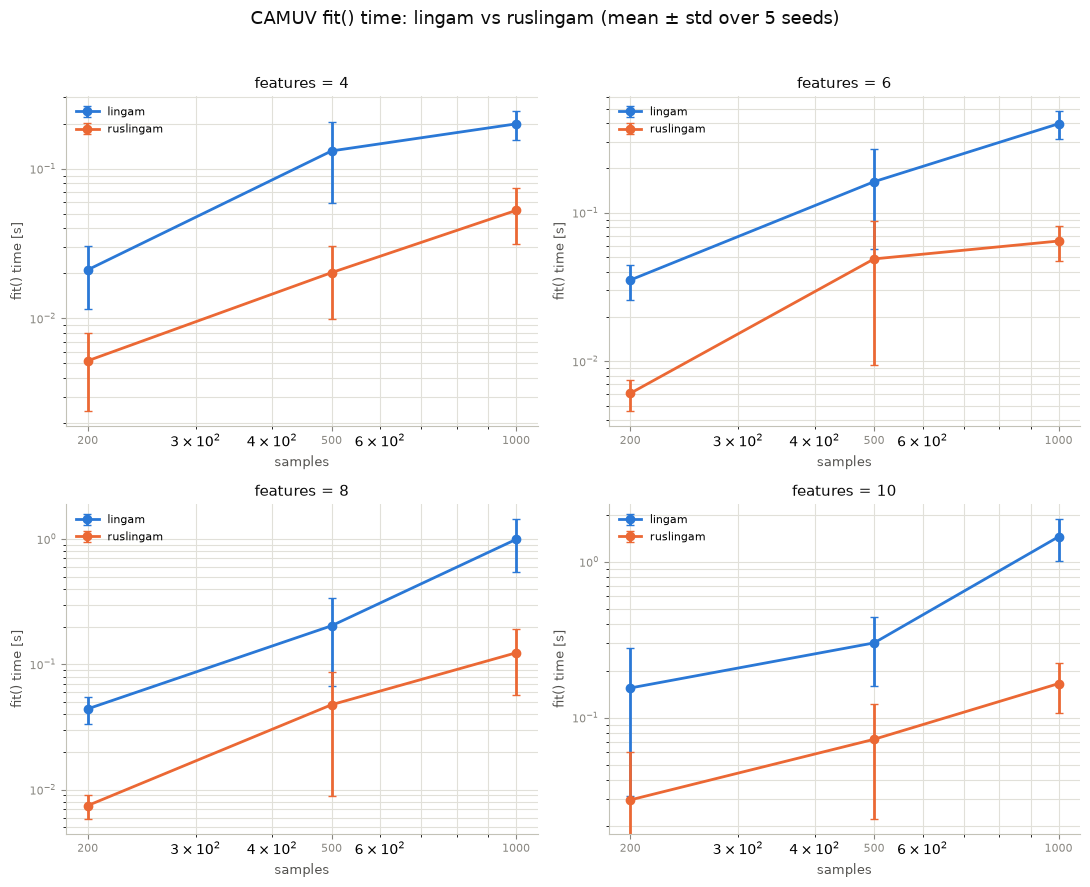

In [6]:
# dataviz skill's categorical palette (fixed order, never cycled): slot1=blue, slot2=orange
COLOR_LINGAM = "#2a78d6"
COLOR_RUSLINGAM = "#eb6834"
GRID_COLOR = "#e1e0d9"
AXIS_COLOR = "#c3c2b7"
TEXT_MUTED = "#898781"
TEXT_SECONDARY = "#52514e"
TEXT_PRIMARY = "#0b0b0b"

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for ax, p in zip(axes, FEATURE_SIZES):
    sub = summary[summary["features"] == p].sort_values("samples")
    ax.errorbar(
        sub["samples"], sub["lingam_mean"], yerr=sub["lingam_std"],
        marker="o", markersize=6, linewidth=2, color=COLOR_LINGAM, label="lingam",
        capsize=3,
    )
    ax.errorbar(
        sub["samples"], sub["ruslingam_mean"], yerr=sub["ruslingam_std"],
        marker="o", markersize=6, linewidth=2, color=COLOR_RUSLINGAM, label="ruslingam",
        capsize=3,
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xticks(SAMPLE_SIZES)
    ax.set_xticklabels([str(s) for s in SAMPLE_SIZES])
    ax.set_title(f"features = {p}", color=TEXT_PRIMARY, fontsize=11)
    ax.set_xlabel("samples", color=TEXT_SECONDARY, fontsize=9)
    ax.set_ylabel("fit() time [s]", color=TEXT_SECONDARY, fontsize=9)
    ax.grid(True, which="both", color=GRID_COLOR, linewidth=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(AXIS_COLOR)
    ax.spines["bottom"].set_color(AXIS_COLOR)
    ax.tick_params(colors=TEXT_MUTED, labelsize=8)
    ax.legend(fontsize=8, frameon=False)

for ax in axes[len(FEATURE_SIZES):]:
    ax.axis("off")

fig.suptitle(
    "CAMUV fit() time: lingam vs ruslingam (mean \u00b1 std over 5 seeds)",
    color=TEXT_PRIMARY, fontsize=13,
)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Table

Shows the same aggregated data as the charts above, in table form.

In [7]:
display_df = summary.copy()
display_df["lingam"] = [f"{m:.3f}s \u00b1 {s:.3f}" for m, s in zip(summary["lingam_mean"], summary["lingam_std"])]
display_df["ruslingam"] = [f"{m:.3f}s \u00b1 {s:.3f}" for m, s in zip(summary["ruslingam_mean"], summary["ruslingam_std"])]
display_df["speedup"] = summary["speedup"].map(lambda x: f"{x:.1f}x")
display_df["match_rate"] = summary["match_rate"].map(lambda x: f"{x * 100:.0f}%")
display_df = display_df[["features", "samples", "lingam", "ruslingam", "speedup", "match_rate"]]
display_df

,features,samples,lingam,ruslingam,speedup,match_rate
0,4,200,0.021s ± 0.010,0.005s ± 0.003,4.1x,100%
1,4,500,0.132s ± 0.072,0.020s ± 0.010,6.5x,100%
2,4,1000,0.200s ± 0.043,0.053s ± 0.021,3.8x,100%
3,6,200,0.035s ± 0.009,0.006s ± 0.001,5.8x,100%
4,6,500,0.162s ± 0.105,0.049s ± 0.039,3.3x,100%
5,6,1000,0.397s ± 0.085,0.065s ± 0.017,6.2x,100%
6,8,200,0.044s ± 0.011,0.007s ± 0.002,5.9x,100%
7,8,500,0.203s ± 0.136,0.048s ± 0.039,4.3x,100%
8,8,1000,0.994s ± 0.449,0.124s ± 0.067,8.0x,100%
9,10,200,0.155s ± 0.123,0.030s ± 0.031,5.2x,100%


## Summary

In [8]:
print(
    f"speedup (mean-of-5): min {summary['speedup'].min():.1f}x   "
    f"median {summary['speedup'].median():.1f}x   max {summary['speedup'].max():.1f}x"
)
if (summary["match_rate"] < 1.0).any():
    print("WARNING: adjacency_matrix_ disagreed on at least one (features, samples, seed) combination")
else:
    print("adjacency_matrix_ matched between lingam and ruslingam on every (features, samples, seed) combination")

speedup (mean-of-5): min 3.3x   median 5.5x   max 8.8x
adjacency_matrix_ matched between lingam and ruslingam on every (features, samples, seed) combination
